# Objetivo do projeto:🎯

Este notebook contempla a criação de um modelo preditivo para preços de casas a base de dados "house_prices".

Fonte https://github.com/tbagalhi/portfolio/blob/main/house_prices.csv

In [1]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

1...............................................importação da base

Este bloco de código carrega um conjunto de dados de preços de casas a partir de um arquivo CSV chamado house_prices.csv utilizando o pandas (pd.read_csv). O DataFrame resultante é armazenado na variável base_casas e exibido diretamente, permitindo uma visualização inicial dos dados carregados. Esta etapa é fundamental para inspecionar as primeiras linhas do dataset e garantir que os dados foram importados corretamente.

In [2]:
base_casas = pd.read_csv('house_prices.csv')
base_casas

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


# Descritivo

Este bloco de código fornece uma visão estatística geral do DataFrame base_casas utilizando o método describe() do pandas. Ele gera um resumo com as principais estatísticas descritivas para cada coluna numérica, incluindo contagem, média, desvio padrão, valores mínimos e máximos, bem como os quartis. Este resumo é essencial para entender a distribuição dos dados e identificar possíveis outliers ou anomalias no conjunto de dados.

In [3]:
base_casas.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Este bloco de código verifica a presença de valores ausentes (nulos) no DataFrame base_casas. Utilizando o método isnull() combinado com sum(), ele conta o número total de valores nulos em cada coluna do dataset. O resultado fornece uma visão geral da qualidade dos dados, indicando quais colunas possuem valores ausentes que podem precisar de tratamento antes da análise ou modelagem.

In [4]:
base_casas.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

2...............................................análise de correlação

Este bloco de código cria uma matriz de correlação para o DataFrame base_casas utilizando o método corr(), que calcula os coeficientes de correlação entre todas as variáveis numéricas do dataset. Os valores são arredondados para duas casas decimais com o round(2). Em seguida, a matriz de correlação é visualizada através de um mapa de calor (heatmap) utilizando a biblioteca Seaborn (sns.heatmap). O gráfico é configurado com anotações dos coeficientes de correlação, linhas separadoras e uma paleta de cores "coolwarm". Esta visualização é útil para identificar relações lineares entre as variáveis e detectar possíveis multicolinearidades no conjunto de dados.

C:\Users\thiag\AppData\Local\Temp\ipykernel_11660\909607238.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = base_casas.corr().round(2)


<Axes: >

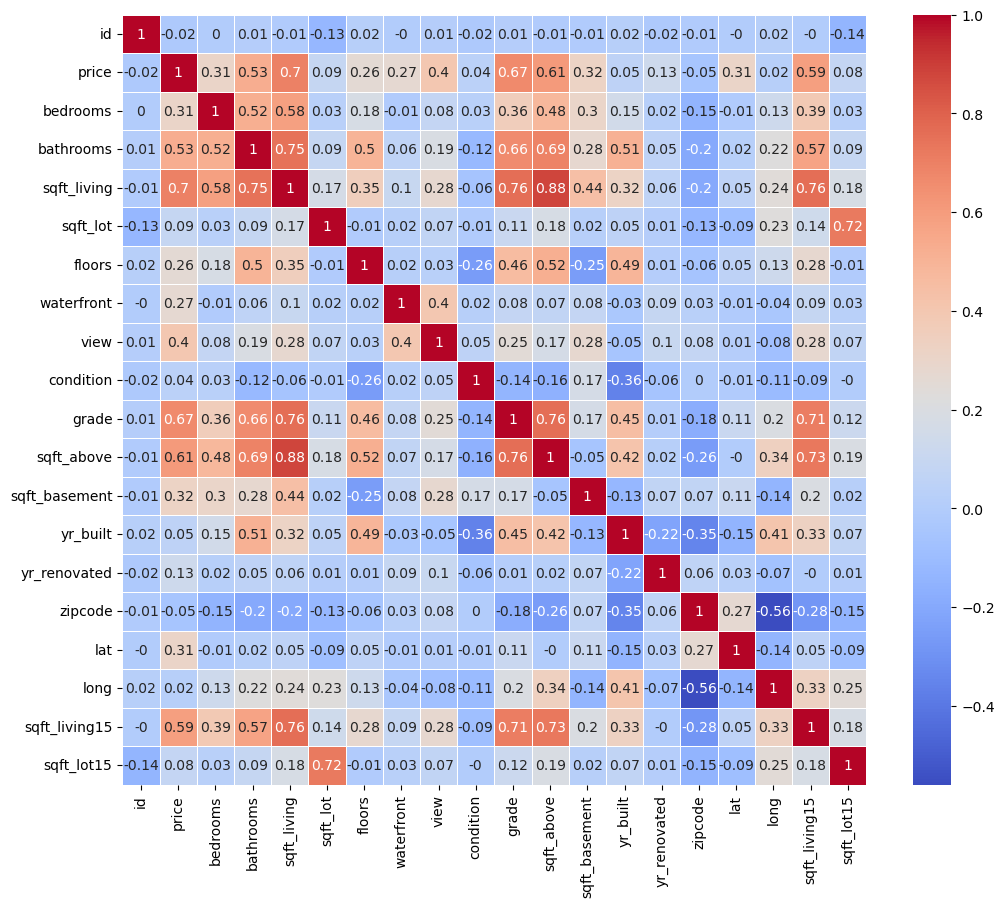

In [6]:
correlation_matrix = base_casas.corr().round(2)
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(data = correlation_matrix, annot= True,linewidths=.5, ax=ax, cmap='coolwarm')

# Separação entre Features e target

Este bloco de código seleciona um subconjunto das colunas do DataFrame base_casas para criar a matriz de variáveis independentes, X_casas. Utilizando o método iloc[], as colunas da 3ª à 18ª (indexadas de 0 a 18) são extraídas e convertidas em um array numpy com .values. Este array será utilizado posteriormente como entrada para modelos de machine learning, contendo as features (características) do dataset que serão usadas para prever variáveis de interesse.

In [7]:
X_casas = base_casas.iloc[:,3:19].values
X_casas

array([[ 3.00000e+00,  1.00000e+00,  1.18000e+03, ...,  9.81780e+04,
         4.75112e+01, -1.22257e+02],
       [ 3.00000e+00,  2.25000e+00,  2.57000e+03, ...,  9.81250e+04,
         4.77210e+01, -1.22319e+02],
       [ 2.00000e+00,  1.00000e+00,  7.70000e+02, ...,  9.80280e+04,
         4.77379e+01, -1.22233e+02],
       ...,
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75944e+01, -1.22299e+02],
       [ 3.00000e+00,  2.50000e+00,  1.60000e+03, ...,  9.80270e+04,
         4.75345e+01, -1.22069e+02],
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75941e+01, -1.22299e+02]])

Este bloco de código extrai a coluna de resposta ou variável dependente do DataFrame base_casas, armazenando-a na variável y_casas. A coluna selecionada é a de índice 2 (a terceira coluna do DataFrame), utilizando o método iloc[]. Os valores são convertidos em um array numpy com .values. Esta variável y_casas conterá os valores que se deseja prever com os modelos de machine learning, geralmente representando o alvo (target) do modelo.

In [8]:
y_casas = base_casas.iloc[:,2].values
y_casas

array([221900., 538000., 180000., ..., 402101., 400000., 325000.])

# Separar Treino e teste

Este bloco de código realiza a divisão do conjunto de dados em conjuntos de treinamento e teste. Utilizando a função train_test_split da biblioteca scikit-learn, o array de features (X_casas) e o array alvo (y_casas) são divididos em duas partes: 70% dos dados são alocados para o conjunto de treinamento (X_casas_treinamento e y_casas_treinamento), e os 30% restantes são destinados ao conjunto de teste (X_casas_teste e y_casas_teste). O parâmetro random_state = 0 garante que a divisão dos dados seja reprodutível. Essa separação é fundamental para avaliar o desempenho do modelo, treinando-o em um subconjunto dos dados e testando-o em outro para validar sua capacidade de generalização.

In [9]:
from sklearn.model_selection import train_test_split
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.3, random_state = 0)

In [10]:
X_casas_treinamento.shape, y_casas_treinamento.shape

((15129, 16), (15129,))

In [11]:
X_casas_teste.shape,y_casas_teste.shape

((6484, 16), (6484,))

# Algorítmo de Árvores de Regressão

Este bloco de código treina um modelo de regressão utilizando uma Árvore de Decisão (DecisionTreeRegressor) da biblioteca scikit-learn. O modelo é instanciado na variável regressor_arvore_casas sem parâmetros específicos, utilizando os valores padrão. Em seguida, o modelo é treinado com o método fit() usando o conjunto de treinamento X_casas_treinamento (variáveis independentes) e y_casas_treinamento (variável dependente). A Árvore de Decisão é um algoritmo de aprendizado supervisionado que será usado para prever valores contínuos, como o preço das casas.

In [12]:
#Treinamento do modelo
from sklearn.tree import DecisionTreeRegressor
regressor_arvore_casas = DecisionTreeRegressor()
regressor_arvore_casas.fit(X_casas_treinamento, y_casas_treinamento)



DecisionTreeRegressor()

Este bloco de código avalia o desempenho do modelo de Árvore de Decisão (regressor_arvore_casas) no conjunto de treinamento. O método score() é utilizado para calcular o coeficiente de determinação, conhecido como 𝑅2, que indica a proporção da variabilidade dos dados de resposta que é explicada pelo modelo. O 𝑅2 varia de 0 a 1, onde valores próximos de 1 indicam um bom ajuste do modelo aos dados de treinamento. Esta métrica é útil para verificar como o modelo se ajusta aos dados que ele foi treinado, mas não deve ser o único critério para avaliar o modelo, já que é importante também verificar seu desempenho no conjunto de teste.

In [13]:
#Avaliação da base de treinamento
regressor_arvore_casas.score(X_casas_treinamento, y_casas_treinamento)

0.9992712177726063

Este bloco de código avalia o desempenho do modelo de Árvore de Decisão (regressor_arvore_casas) no conjunto de teste. Novamente, o método score() é utilizado para calcular o coeficiente de determinação R2.

In [14]:
#Avaliação da base de teste
regressor_arvore_casas.score(X_casas_teste, y_casas_teste)

0.7150464786147381

# Avaliação

Este bloco de código utiliza o modelo de Árvore de Decisão (regressor_arvore_casas) previamente treinado para fazer previsões sobre o conjunto de teste. O método predict() é aplicado às variáveis independentes do conjunto de teste (X_casas_teste), gerando previsões que são armazenadas na variável previsoes. Estas previsões representam os valores estimados da variável dependente (neste caso, o preço das casas) para cada observação no conjunto de teste. As previsões podem ser comparadas aos valores reais para avaliar a precisão do modelo.

In [15]:
previsoes = regressor_arvore_casas.predict(X_casas_teste)
previsoes

array([ 288000., 1835000.,  480000., ...,  289000.,  215000.,  201000.])

Este bloco de código calcula o Erro Absoluto Médio (MAE, do inglês Mean Absolute Error) para avaliar a performance do modelo de Árvore de Decisão nas previsões feitas sobre o conjunto de teste. O MAE é uma métrica que mede a média das diferenças absolutas entre os valores reais (y_casas_teste) e as previsões do modelo (previsoes). Um MAE menor indica que as previsões estão mais próximas dos valores reais, sendo uma métrica interpretável em termos das mesmas unidades da variável dependente (neste caso, o preço das casas). Essa métrica é útil para entender o desempenho do modelo em termos de erro médio

In [17]:
#MAE (Mean Absolute Error)
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error (y_casas_teste, previsoes)


98888.15098704504

Este bloco de código calcula o Erro Quadrático Médio (MSE, do inglês Mean Squared Error), que é uma métrica de avaliação para medir a média dos quadrados das diferenças entre os valores reais (y_casas_teste) e as previsões do modelo (previsoes). Diferente do MAE, o MSE penaliza erros maiores com mais intensidade, já que as diferenças são elevadas ao quadrado antes de serem somadas e, em seguida, divididas pelo número de observações. Um MSE menor indica um melhor desempenho do modelo, sugerindo que as previsões estão, em média, mais próximas dos valores reais.

In [18]:
#MSE (Mean Squared Error)
mean_squared_error(y_casas_teste, previsoes)

39121825076.744064

Este bloco de código calcula a Raiz do Erro Quadrático Médio (RMSE, do inglês Root Mean Squared Error), que é uma métrica de avaliação obtida ao tirar a raiz quadrada do MSE. O RMSE é útil porque apresenta o erro médio em termos das mesmas unidades da variável dependente (neste caso, o preço das casas), tornando-o mais interpretável em comparação ao MSE. Um RMSE menor indica que as previsões do modelo estão, em média, mais próximas dos valores reais, sendo uma métrica eficaz para avaliar a precisão de modelos de regressão.

In [19]:
#RMSE (Root Mean Squared Error)
np.sqrt(mean_squared_error(y_casas_teste, previsoes))

197792.37871248747

# Escalonamento

Este bloco de código aplica a padronização aos conjuntos de treinamento e teste usando a técnica de Standardization. Através da função StandardScaler da biblioteca sklearn, os dados de entrada (X_casas_treinamento e X_casas_teste) são transformados para ter média 0 e desvio padrão 1, o que ajuda a equilibrar as variáveis ao longo da escala e melhora o desempenho de alguns algoritmos de machine learning, como os baseados em distância. A transformação é aplicada após ajustar o scaler ao conjunto de treinamento, garantindo que as mesmas escalas sejam usadas para os dados de teste.

In [28]:
from sklearn.preprocessing import StandardScaler
scaler_x_casas = StandardScaler()

scaler_x_casas.fit(X_casas_treinamento)

X_casas_treinamento_scaled = scaler_x_casas.transform(X_casas_treinamento)
X_casas_teste_scaled = scaler_x_casas.transform(X_casas_teste)


Neste bloco de código, a padronização é aplicada à variável dependente (y_casas_treinamento e y_casas_teste). Utilizando o StandardScaler da biblioteca sklearn, os valores de y_casas são transformados para ter média 0 e desvio padrão 1. Este processo ajuda a equilibrar a escala da variável dependente, especialmente em modelos sensíveis à escala dos dados. A função reshape(-1,1) é utilizada para transformar os dados em uma matriz de duas dimensões, necessária para que o StandardScaler possa realizar a transformação corretamente. As transformações são feitas separadamente para garantir que o modelo não tenha acesso às informações do conjunto de teste durante o treinamento.

In [34]:
scaler_y_casas = StandardScaler()
scaler_y_casas.fit(y_casas_treinamento.reshape(-1,1))

y_casas_treinamento_scaled = scaler_y_casas.transform(y_casas_treinamento.reshape(-1,1))
y_casas_teste_scaled = scaler_y_casas.transform(y_casas_teste.reshape(-1,1))

# Algorítmo de SVM Regressor

Neste bloco de código, um modelo de Regressão por Vetores de Suporte (SVR) é treinado para prever os preços das casas. Utilizando o SVR da biblioteca sklearn, o modelo é configurado com um kernel polinomial de grau 3. O modelo é treinado com os dados de treinamento escalonados (X_casas_treinamento_scaled e y_casas_treinamento_scaled) para aprender a relação entre as variáveis independentes e o preço das casas. O kernel polinomial permite capturar relações não lineares entre as variáveis, o que pode melhorar a performance do modelo em problemas complexos.

In [30]:
#Treinamento
from sklearn.svm import SVR
regressor_svr_casas = SVR(kernel='poly', degree=3)
regressor_svr_casas.fit(X_casas_treinamento_scaled, y_casas_treinamento_scaled)

C:\Users\thiag\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='poly')

O método score do modelo SVR é utilizado para calcular o coeficiente de determinação 𝑅2 na base de treinamento. Esse valor fornece uma medida de quão bem o modelo ajusta os dados de treinamento, sendo um indicador importante para avaliar a eficácia do modelo na previsão dos preços das casas.

In [31]:
#Avaliação da base de treinamento
regressor_svr_casas.score(X_casas_treinamento_scaled, y_casas_treinamento_scaled)

0.776964259874281

Este bloco de código avalia o desempenho do modelo de Regressão por Vetores de Suporte (SVR) na base de teste. O método score calcula o coeficiente de determinação R2 para o conjunto de teste (X_casas_teste_scaled e y_casas_teste_scaled). Este valor indica a capacidade do modelo em explicar a variabilidade dos dados de teste. Um R2 próximo de 1 sugere que o modelo se ajusta bem aos dados de teste e é eficaz em prever os preços das casas.

In [36]:
#Avaliação da base de teste
regressor_svr_casas.score(X_casas_teste_scaled, y_casas_teste_scaled)

0.7079713669657849

# Avaliação

Neste bloco de código, o modelo de Regressão por Vetores de Suporte (SVR) faz previsões sobre o conjunto de teste (X_casas_teste_scaled). As previsões obtidas são ajustadas para uma matriz de duas dimensões usando reshape(-1, 1), o que facilita a comparação com os valores reais ou a realização de análises posteriores. Essas previsões representam os valores estimados do preço das casas com base nas características fornecidas pelo modelo treinado. As previsões podem ser usadas para avaliar a precisão do modelo ou para outros fins analíticos.

In [37]:
previsoes = regressor_svr_casas.predict(X_casas_teste_scaled).reshape(-1, 1)
previsoes


array([[-0.49961641],
       [ 4.15027404],
       [-0.07315919],
       ...,
       [-0.76596006],
       [-0.60967016],
       [-0.62432977]])

Neste bloco de código, a padronização aplicada à variável dependente (y_casas_teste_scaled) e às previsões (previsoes) é revertida para os valores originais usando o método inverse_transform do scaler_y_casas. A transformação inversa é necessária para interpretar os resultados em termos das unidades originais dos preços das casas, permitindo uma comparação direta entre os valores reais e as previsões. Esse processo é crucial para avaliar a precisão do modelo e para realizar análises de desempenho em termos compreensíveis e relevantes para o problema.

In [38]:
#Revertendo a padronização
y_casas_teste_inverse = scaler_y_casas.inverse_transform(y_casas_teste_scaled)
previsoes_inverse = scaler_y_casas.inverse_transform(previsoes)

Este bloco de código calcula o Erro Absoluto Médio (MAE, do inglês Mean Absolute Error) para avaliar a performance do modelo de Árvore de Decisão nas previsões feitas sobre o conjunto de teste. O MAE é uma métrica que mede a média das diferenças absolutas entre os valores reais (y_casas_teste) e as previsões do modelo (previsoes). Um MAE menor indica que as previsões estão mais próximas dos valores reais, sendo uma métrica interpretável em termos das mesmas unidades da variável dependente (neste caso, o preço das casas). Essa métrica é útil para entender o desempenho do modelo em termos de erro médio

In [39]:
#MAE (Mean Absolute Error)
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error (y_casas_teste_inverse, previsoes_inverse)



113024.85718685346

Este bloco de código calcula o Erro Quadrático Médio (MSE, do inglês Mean Squared Error), que é uma métrica de avaliação para medir a média dos quadrados das diferenças entre os valores reais (y_casas_teste) e as previsões do modelo (previsoes). Diferente do MAE, o MSE penaliza erros maiores com mais intensidade, já que as diferenças são elevadas ao quadrado antes de serem somadas e, em seguida, divididas pelo número de observações. Um MSE menor indica um melhor desempenho do modelo, sugerindo que as previsões estão, em média, mais próximas dos valores reais.

In [40]:
#RMSE (Root Mean Squared Error)
np.sqrt(mean_squared_error(y_casas_teste_inverse, previsoes_inverse))

200232.8168984212

Este bloco de código calcula a Raiz do Erro Quadrático Médio (RMSE, do inglês Root Mean Squared Error), que é uma métrica de avaliação obtida ao tirar a raiz quadrada do MSE. O RMSE é útil porque apresenta o erro médio em termos das mesmas unidades da variável dependente (neste caso, o preço das casas), tornando-o mais interpretável em comparação ao MSE. Um RMSE menor indica que as previsões do modelo estão, em média, mais próximas dos valores reais, sendo uma métrica eficaz para avaliar a precisão de modelos de regressão.

In [41]:
#MSE (Mean Squared Error)
mean_squared_error(y_casas_teste_inverse, previsoes_inverse)

40093180963.076675